# Spaceship Titanic — Tabular Classification Prototype
**SYS-304 Scalable Algorithms and Infrastructure — Milestone 1**

**Problem**: Predict whether a passenger was `Transported` to an alternate dimension during the *Spaceship Titanic*'s collision with a spacetime anomaly, using tabular passenger data (demographics, cabin, spending on ship amenities).

This notebook covers:
1. Data loading
2. Exploratory Data Analysis (EDA)
3. Feature engineering & preprocessing
4. Baseline model training (Random Forest + XGBoost)
5. Evaluation
6. Saving the trained model weights


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

from xgboost import XGBClassifier

import pickle

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


## 1. Load Data

In [2]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
train_df.head()


Train shape: (8693, 14)
Test shape: (4277, 13)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


## 2. Exploratory Data Analysis

In [3]:
train_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   str    
 1   HomePlanet    8492 non-null   str    
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   str    
 4   Destination   8511 non-null   str    
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   str    
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(2), str(5)
memory usage: 891.5+ KB


In [4]:
# Missing values per column
missing = train_df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(train_df) * 100).round(2)
pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})


,missing_count,missing_pct
CryoSleep,217,2.50
ShoppingMall,208,2.39
VIP,203,2.34
HomePlanet,201,2.31
Name,200,2.30
Cabin,199,2.29
VRDeck,188,2.16
Spa,183,2.11
FoodCourt,183,2.11
Destination,182,2.09


In [5]:
# Target distribution
train_df["Transported"].value_counts(normalize=True)


Transported
True     0.503624
False    0.496376
Name: proportion, dtype: float64

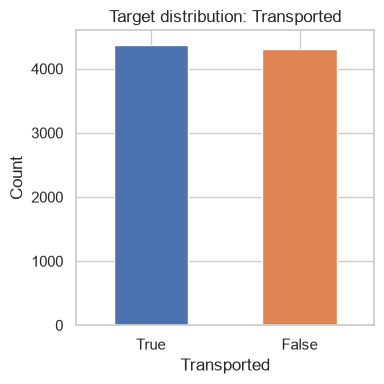

In [6]:
fig, ax = plt.subplots(figsize=(4, 4))
train_df["Transported"].value_counts().plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452"])
ax.set_title("Target distribution: Transported")
ax.set_xlabel("Transported")
ax.set_ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


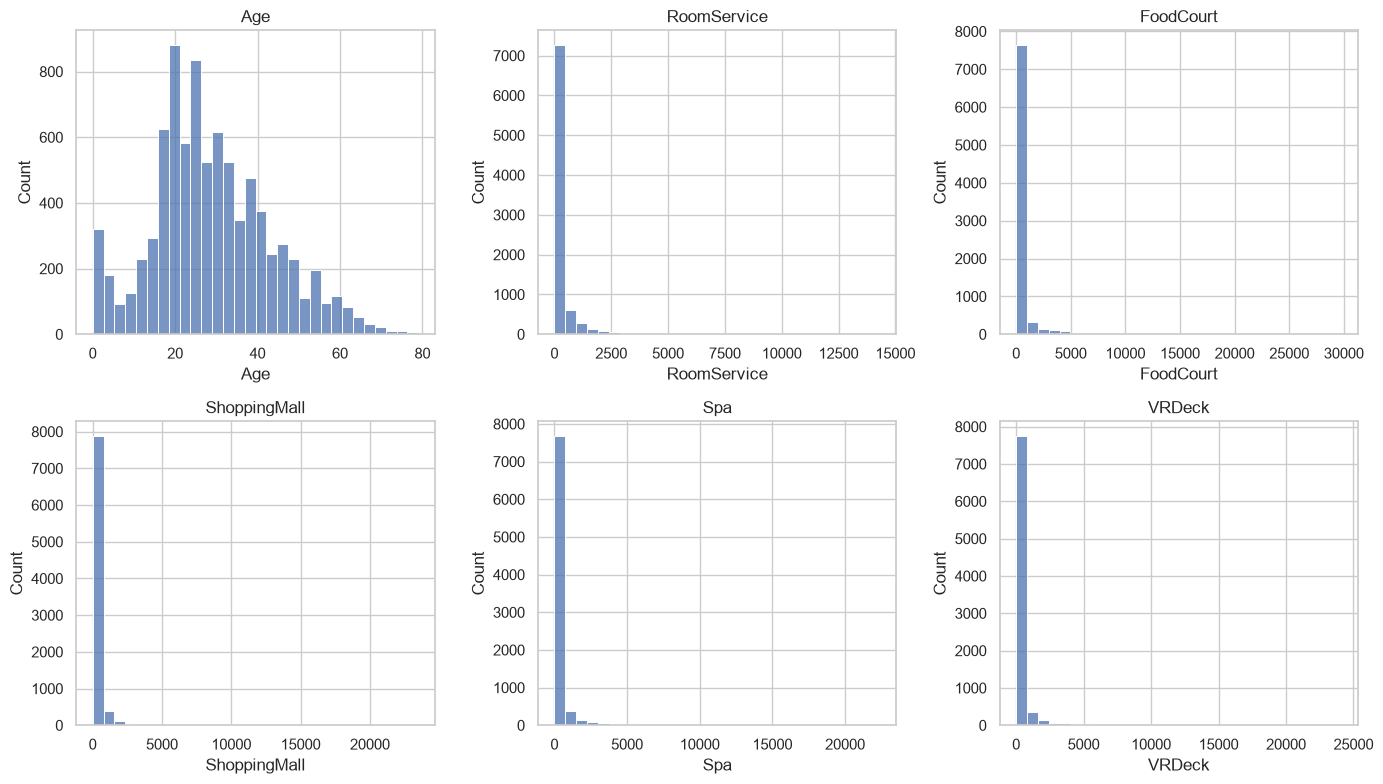

In [7]:
numeric_cols = ["Age", "RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for col, ax in zip(numeric_cols, axes.ravel()):
    sns.histplot(train_df[col].dropna(), bins=30, ax=ax, kde=False)
    ax.set_title(col)
plt.tight_layout()
plt.show()


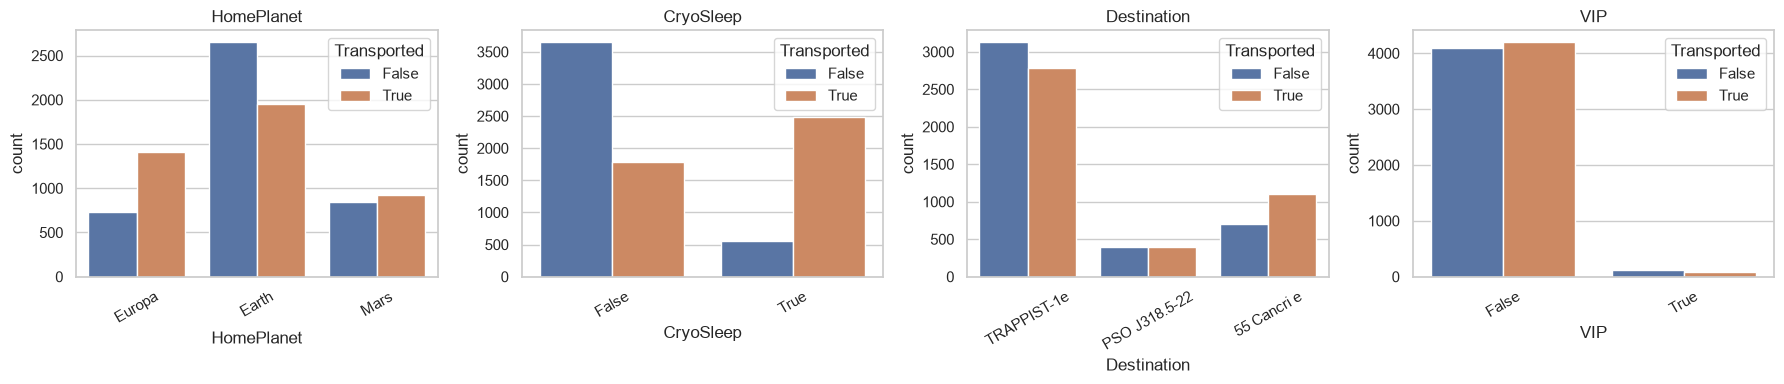

In [8]:
categorical_cols = ["HomePlanet", "CryoSleep", "Destination", "VIP"]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for col, ax in zip(categorical_cols, axes.ravel()):
    sns.countplot(data=train_df, x=col, hue="Transported", ax=ax)
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


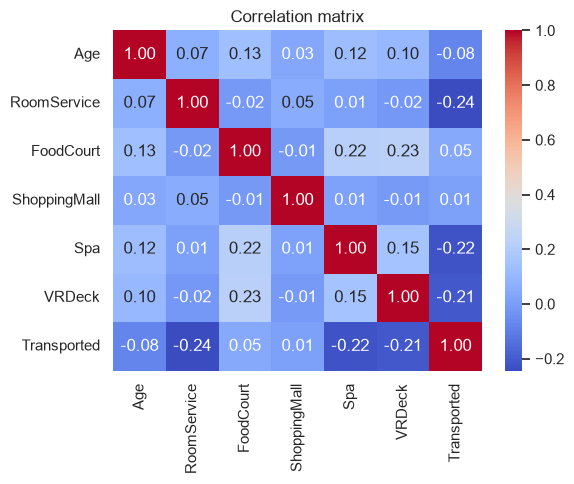

In [9]:
# Correlation among numeric features + target
corr_df = train_df[numeric_cols + ["Transported"]].copy()
corr_df["Transported"] = corr_df["Transported"].astype(int)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
ax.set_title("Correlation matrix")
plt.tight_layout()
plt.show()


**EDA takeaways**
- `CryoSleep`, `HomePlanet`, and spending columns show the clearest split against `Transported`.
- Several columns have missing values (`CryoSleep`, `Cabin`, spending columns, `HomePlanet`, etc.) — need imputation.
- `Cabin` (`Deck/Num/Side`) and `PassengerId` (`Group_Member`) are compound fields — worth splitting into engineered features.
- Spending columns are heavily right-skewed (many zeros, some large values) — consistent with CryoSleep passengers spending nothing.


## 3. Feature Engineering

In [10]:
def engineer_features(df):
    df = df.copy()

    # Split Cabin -> Deck / CabinNum / Side
    cabin_split = df["Cabin"].str.split("/", expand=True)
    df["Deck"] = cabin_split[0]
    df["CabinNum"] = pd.to_numeric(cabin_split[1], errors="coerce")
    df["Side"] = cabin_split[2]

    # Split PassengerId -> Group / GroupSize
    df["Group"] = df["PassengerId"].str.split("_").str[0]
    group_sizes = df["Group"].value_counts()
    df["GroupSize"] = df["Group"].map(group_sizes)

    # Total spend across amenities
    spend_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
    df["TotalSpend"] = df[spend_cols].fillna(0).sum(axis=1)

    return df

train_fe = engineer_features(train_df)
test_fe = engineer_features(test_df)

train_fe[["PassengerId", "Group", "GroupSize", "Cabin", "Deck", "CabinNum", "Side", "TotalSpend"]].head()


,PassengerId,Group,GroupSize,Cabin,Deck,CabinNum,Side,TotalSpend
0,0001_01,0001,1,B/0/P,B,0.0,P,0.0
1,0002_01,0002,1,F/0/S,F,0.0,S,736.0
2,0003_01,0003,2,A/0/S,A,0.0,S,10383.0
3,0003_02,0003,2,A/0/S,A,0.0,S,5176.0
4,0004_01,0004,1,F/1/S,F,1.0,S,1091.0


## 4. Train / Validation Split & Preprocessing Pipeline

In [11]:
feature_cols = [
    "HomePlanet", "CryoSleep", "Destination", "Age", "VIP",
    "RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck",
    "Deck", "CabinNum", "Side", "GroupSize", "TotalSpend",
]

X = train_fe[feature_cols]
y = train_fe["Transported"].astype(int)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train:", X_train.shape, " Val:", X_val.shape)


Train: (6954, 15)  Val: (1739, 15)


In [12]:
numeric_features = ["Age", "RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck",
                     "CabinNum", "GroupSize", "TotalSpend"]
categorical_features = ["HomePlanet", "CryoSleep", "Destination", "VIP", "Deck", "Side"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])


## 5. Baseline Model Training

In [13]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=300, max_depth=None, random_state=RANDOM_STATE, n_jobs=-1)),
])

rf_pipeline.fit(X_train, y_train)

rf_val_preds = rf_pipeline.predict(X_val)
rf_acc = accuracy_score(y_val, rf_val_preds)
print(f"Random Forest validation accuracy: {rf_acc:.4f}")


Random Forest validation accuracy: 0.8091


In [14]:
xgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=400,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        eval_metric="logloss",
        n_jobs=-1,
    )),
])

xgb_pipeline.fit(X_train, y_train)

xgb_val_preds = xgb_pipeline.predict(X_val)
xgb_acc = accuracy_score(y_val, xgb_val_preds)
print(f"XGBoost validation accuracy: {xgb_acc:.4f}")


XGBoost validation accuracy: 0.8137


## 6. Evaluation

In [15]:
best_name, best_pipeline, best_preds = (
    ("XGBoost", xgb_pipeline, xgb_val_preds) if xgb_acc >= rf_acc else ("Random Forest", rf_pipeline, rf_val_preds)
)
print(f"Best model: {best_name} (val accuracy = {accuracy_score(y_val, best_preds):.4f})")
print()
print(classification_report(y_val, best_preds, target_names=["Not Transported", "Transported"]))


Best model: XGBoost (val accuracy = 0.8137)

                 precision    recall  f1-score   support

Not Transported       0.81      0.82      0.81       863
    Transported       0.82      0.81      0.81       876

       accuracy                           0.81      1739
      macro avg       0.81      0.81      0.81      1739
   weighted avg       0.81      0.81      0.81      1739



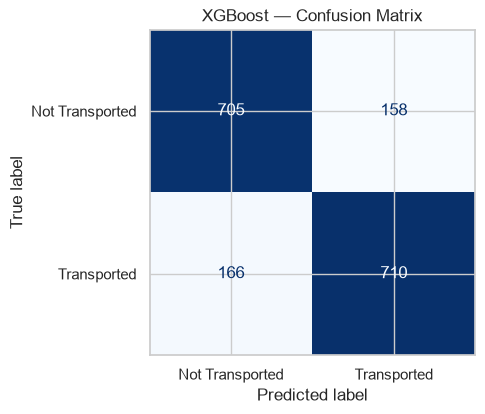

In [16]:
cm = confusion_matrix(y_val, best_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Transported", "Transported"])
fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"{best_name} — Confusion Matrix")
plt.tight_layout()
plt.show()


## 7. Save Baseline Model

In [17]:
with open("baseline_model.pkl", "wb") as f:
    pickle.dump(best_pipeline, f)

print(f"Saved {best_name} pipeline to baseline_model.pkl")


Saved XGBoost pipeline to baseline_model.pkl


## 8. Inference Demo (loading saved weights + predicting)

In [18]:
with open("baseline_model.pkl", "rb") as f:
    loaded_model = pickle.load(f)

sample = X_val.iloc[:10]
sample_preds = loaded_model.predict(sample)
sample_proba = loaded_model.predict_proba(sample)[:, 1]

results = sample.copy()
results["Predicted_Transported"] = sample_preds.astype(bool)
results["Probability"] = sample_proba.round(3)
results["Actual_Transported"] = y_val.iloc[:10].values.astype(bool)
results


,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Deck,CabinNum,Side,GroupSize,TotalSpend,Predicted_Transported,Probability,Actual_Transported
3586,Europa,True,55 Cancri e,34.0,False,0.0,0.0,NaN,0.0,0.0,E,230.0,P,1,0.0,True,0.974,True
7173,Earth,True,TRAPPIST-1e,4.0,False,0.0,0.0,0.0,0.0,0.0,G,1242.0,S,5,0.0,True,0.765,False
8559,Mars,False,TRAPPIST-1e,25.0,False,410.0,32.0,14.0,1239.0,10.0,F,1766.0,S,1,1705.0,False,0.012,False
6528,Mars,False,TRAPPIST-1e,12.0,NaN,0.0,0.0,0.0,0.0,0.0,F,1319.0,S,3,0.0,True,0.964,True
7934,Europa,False,55 Cancri e,66.0,True,0.0,1828.0,1.0,1873.0,45.0,E,556.0,S,1,3747.0,False,0.091,False
1683,Earth,True,PSO J318.5-22,21.0,False,0.0,0.0,0.0,NaN,0.0,G,281.0,S,2,0.0,True,0.568,False
499,Europa,True,TRAPPIST-1e,NaN,False,0.0,0.0,NaN,0.0,0.0,C,18.0,P,5,0.0,True,0.987,True
3850,Europa,NaN,TRAPPIST-1e,23.0,False,0.0,0.0,0.0,0.0,NaN,B,130.0,P,1,0.0,True,0.664,True
8351,Earth,False,TRAPPIST-1e,23.0,False,0.0,0.0,0.0,912.0,41.0,F,1727.0,S,1,953.0,False,0.087,False
7679,Earth,True,PSO J318.5-22,22.0,False,0.0,0.0,0.0,0.0,0.0,G,1330.0,P,1,0.0,True,0.685,True


## 9. Generate Kaggle-style Submission (test set)

In [19]:
test_preds = loaded_model.predict(test_fe[feature_cols])

submission = pd.DataFrame({
    "PassengerId": test_fe["PassengerId"],
    "Transported": test_preds.astype(bool),
})
submission.to_csv("submission.csv", index=False)
submission.head()


,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True
